In [1]:
import yaml
from pathlib import Path
import os
from swiss_roll import RUNS_DIR, DATA_DIR, CONF_DIR
import pandas as pd

In [2]:
guidance_runs_path = RUNS_DIR / 'guidance_models'

print('Guidance run path exists:', guidance_runs_path.exists())

metrics_filename = 'eval_metrics.yaml'

Guidance run path exists: True


In [3]:
metrics_list = []
successful_runs = []  
for root, dirs, _ in guidance_runs_path.walk():
    for dir in dirs:  
        metrics_path = root / dir / metrics_filename
        with open(metrics_path, 'r') as f:
            metrics = yaml.load(f, yaml.FullLoader)

        run_id =  int(dir.split("_")[-1])
        successful_runs.append(run_id)
        metrics['run_id'] = run_id
        metrics_list.append(metrics)

metrics_dataframe = pd.DataFrame.from_records(metrics_list)

In [4]:
guidance_confs_path = CONF_DIR / 'guidance_conf'

print('Guidance run path exists:', guidance_runs_path.exists())

Guidance run path exists: True


In [5]:
conf_list = []
failed_conf_list = []  
for root, _, files in guidance_confs_path.walk():
    for file in files: 
        conf_path = root / file
        with open(conf_path, 'r') as f:
            conf = yaml.load(f, yaml.FullLoader)
       
        run_id =  int(file.split('.')[0]) 
        conf['run_id'] = run_id
       
        if run_id in successful_runs:
            conf_list.append(conf)
        else: 
            failed_conf_list.append(conf)

conf_dataframe = pd.DataFrame.from_records(conf_list)
failed_conf_dataframe = pd.DataFrame.from_records(failed_conf_list)

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from swiss_roll.utils import load_swissroll, load_model
from swiss_roll.guidance import GuidanceModel, GuidanceBlock 

device = 'cpu'
X, Y, _, _ = load_swissroll(split=False)
X = X[:, [0, 2]]
run_id = 204
model_path = guidance_runs_path / f"run_{str(run_id)}" / "guidance_model.pth"

model = load_model(GuidanceModel, model_path)

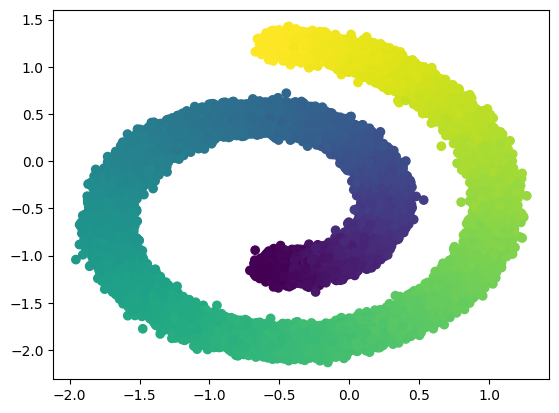

In [32]:
plt.scatter(X[:, 0], X[:, 1], c=Y)

In [45]:
preds = model(X)
pred_means = preds[:, :1]
pred_logvar = preds[:, 1:]
pred_means = pred_means.to(device).detach().numpy()
pred_logvar = pred_logvar.to(device).detach().numpy()

logvar_min = -5
logvar_max = 0.9

mu_min = -2
mu_max = 1

TypeError: Colorbar.__init__() got an unexpected keyword argument 'vmin'

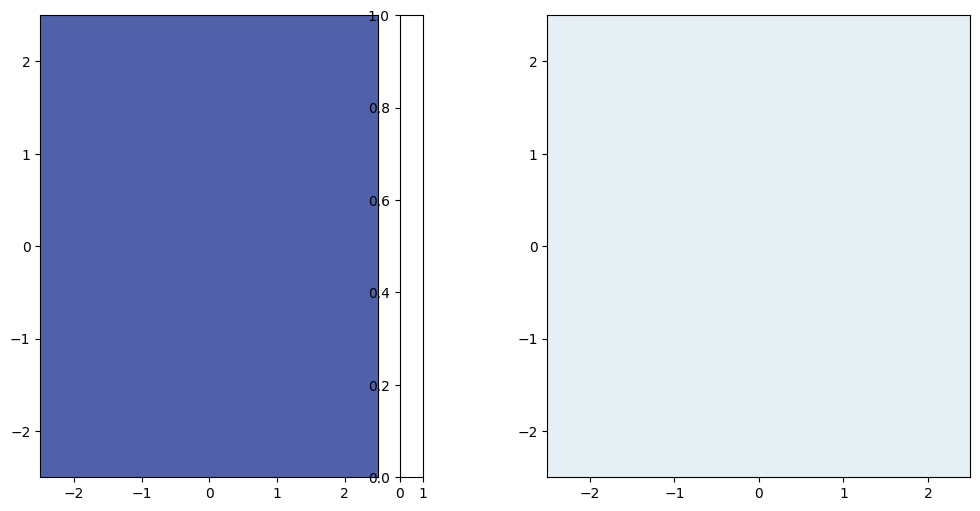

In [ ]:
n = 300
x1_lin = x2_lin = np.linspace(-2.5, 2.5, n)
XX, YY = np.meshgrid(x1_lin, x2_lin)
grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
with torch.no_grad():
    inp = torch.from_numpy(grid).float().to(device)
    pred = model(inp)
mu = pred[:, :1]
logvar = pred[:, 1:]
ZZ = np.round(logvar.cpu().numpy().reshape(XX.shape), 2)
ZZ_mu = np.round(mu.cpu().numpy().reshape(XX.shape), 2)

fig, ax = plt.subplots(1, 2, figsize=(12,6))
cf = ax[0].contourf(XX, YY, ZZ, levels=20, cmap='Spectral')
cf2 = ax[1].contourf(XX, YY, ZZ_mu, levels=20, cmap='RdBu')
fig.colorbar(cf, ax=ax[0], label='Predicted log-variance') 
fig.colorbar(cf2, ax=ax[1], label='Predicted mean')

idx = torch.randperm(len(X))[: 10_000]
ax[0].scatter(X[idx, 0], X[idx, 1], c=pred_logvar[idx], alpha=0.5, edgecolors='black', cmap='Spectral')
ax[1].scatter(X[idx, 0], X[idx, 1], c=pred_means[idx], alpha=0.5, edgecolors='black', cmap='RdBu')
